In [1]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("jasonrobinson1/animal-health-incident-reports")

# List all files in the dataset
files = os.listdir(path)

# Load the CSV file (adjust filename if needed)
df = pd.read_csv(os.path.join(path, files[2]))

In [2]:
# Check variables / columns
print("\n--- Shape ---")
print(df.shape)


--- Shape ---
(5579, 13)


In [3]:
print("\n--- Column Names ---")
print(df.columns.tolist())


--- Column Names ---
['report_id', 'country', 'region', 'date_reported', 'species', 'disease', 'confirmed_cases', 'deaths', 'outbreak_status', 'notes', 'source', 'latitude', 'longitude']


In [4]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
report_id           object
country             object
region             float64
date_reported       object
species             object
disease             object
confirmed_cases      int64
deaths               int64
outbreak_status     object
notes               object
source              object
latitude           float64
longitude          float64
dtype: object


In [5]:
print("\n--- First 5 Rows ---")
display(df.head())


--- First 5 Rows ---


,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,source,latitude,longitude
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,NaN,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),0,0,Resolved,First occurrence in a zone or a compartment,https://wahis.woah.org,NaN,NaN
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,NaN,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,NaN,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,NaN,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),NaN,2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),0,0,Resolved,First occurrence in the country,https://wahis.woah.org,NaN,NaN


In [6]:
print("\n--- Basic Stats ---")
display(df.describe(include='all'))


--- Basic Stats ---


,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,source,latitude,longitude
count,5579,5579,0.0,5579,5579,5579,5579.0,5579.0,5579,5579,5579,0.0,0.0
unique,5579,187,NaN,2845,7,141,NaN,NaN,1,14,1,NaN,NaN
top,7cda1a50-2034-4b9a-b356-6219c91c13e1,Russia,NaN,2022-06-07,Poultry,High pathogenicity avian influenza viruses (po...,NaN,NaN,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
freq,1,340,NaN,38,2098,966,NaN,NaN,5579,3696,5579,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [7]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
report_id             0
country               0
region             5579
date_reported         0
species               0
disease               0
confirmed_cases       0
deaths                0
outbreak_status       0
notes                 0
source                0
latitude           5579
longitude          5579
dtype: int64


In [8]:
import requests
import io

# Download World Bank country classification (income group + region)
wb_url = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"
wb_response = requests.get(wb_url)
wb_raw = pd.read_excel(io.BytesIO(wb_response.content), sheet_name='List of economies', header=0)

# Keep only relevant columns and clean
wb = wb_raw[['Economy', 'Code', 'Region', 'Income group']].copy()
wb.columns = ['country_wb', 'iso_code', 'wb_region', 'income_group']
wb = wb.dropna(subset=['country_wb'])
wb = wb[wb['income_group'].notna()]  # remove aggregates (continents etc.)

print(f"World Bank data loaded: {len(wb)} countries")
print(wb['income_group'].value_counts())
print(wb['wb_region'].value_counts())

World Bank data loaded: 217 countries
income_group
High income            81
Lower middle income    54
Upper middle income    54
Low income             28
Name: count, dtype: int64
wb_region
Europe & Central Asia         58
Sub-Saharan Africa            48
Latin America & Caribbean     41
East Asia & Pacific           38
Middle East & North Africa    21
South Asia                     8
North America                  3
Name: count, dtype: int64


In [9]:
name_map = {
    # Original mappings
    "China (People's Rep. of)": "China",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Korea (Rep. of)": "Korea, Rep.",
    "Iran (Islamic Rep. of)": "Iran, Islamic Rep.",
    "Taiwan": "Taiwan, China",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Rep. of)": "Venezuela, RB",
    "Tanzania (United Rep. of)": "Tanzania",
    "Congo (Dem. Rep. of the)": "Congo, Dem. Rep.",
    "Congo": "Congo, Rep.",
    "Lao (People's Dem. Rep.)": "Lao PDR",
    "Viet Nam": "Vietnam",
    "Czechia": "Czech Republic",
    "North Macedonia": "North Macedonia",
    "Eswatini": "Eswatini",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Syrian Arab Republic": "Syrian Arab Republic",
    "Libya": "Libya",
    "Kosovo": "Kosovo",

    # Extended mappings
    'Russia': 'Russian Federation',
    'Egypt': 'Egypt, Arab Rep.',
    'Iran': 'Iran, Islamic Rep.',
    'Syria': 'Syrian Arab Republic',
    'Türkiye (Rep. of)': 'Turkiye',
    'Venezuela': 'Venezuela, RB',
    'Slovakia': 'Slovak Republic',
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Laos': 'Lao PDR',
    'Brunei': 'Brunei Darussalam',
    'Gambia': 'Gambia, The',
    "Cote D'Ivoire": "Cote d'Ivoire",
    'Congo (Rep. of the)': 'Congo, Rep.',
    'Central African (Rep.)': 'Central African Republic',
    'Dominican (Rep.)': 'Dominican Republic',
    "Korea (Dem People's Rep. of)": "Korea, Dem. People's Rep.",
    'South Sudan (Rep. of)': 'South Sudan',
    'Cabo verde': 'Cabo Verde',
    'Chinese Taipei': 'Taiwan, China',
    'Hong Kong': 'Hong Kong SAR, China',
    'Venezuela' : 'Venezuela, RB',

    # Territories
    'French Guiana': 'France',
    'Guadeloupe': 'France',
    'Martinique': 'France',
    'Reunion': 'France',
    'Mayotte': 'France',
    'Faeroe Islands': 'Denmark',
    'Falkland Islands (Malvinas)': 'United Kingdom',
    'St. Helena': 'United Kingdom',
    'Ceuta': 'Spain',
    'Melilla': 'Spain',
}

df['country_mapped'] = df['country'].replace(name_map)


In [10]:

df_enriched = df.merge(
    wb[['country_wb', 'iso_code', 'wb_region', 'income_group']],
    left_on='country_mapped',
    right_on='country_wb',
    how='left'
)

# Check merge success rate
total = len(df_enriched)
matched = df_enriched['income_group'].notna().sum()
unmatched = df_enriched[df_enriched['income_group'].isna()]['country'].unique()

print(f"\n Matched: {matched}/{total} ({matched/total*100:.1f}%)")
print(f"\n Unmatched countries ({len(unmatched)}):")
print(sorted(unmatched))


 Matched: 5486/5579 (98.3%)

 Unmatched countries (7):
['Antarctica', "Cote D'Ivoire", 'Palestine', 'Serbia and Montenegro', 'South Georgia and the South Sandwich Islands', 'Türkiye (Rep. of)', 'Venezuela']


In [11]:
df_enriched['date_reported'] = pd.to_datetime(df_enriched['date_reported'], errors='coerce')

df_enriched['year'] = df_enriched['date_reported'].dt.year
df_enriched['month'] = df_enriched['date_reported'].dt.month

# ============================================================
# STEP 7: Final check
# ============================================================

print("\n--- Enriched Dataset Info ---")
print(df_enriched[['country', 'wb_region', 'income_group', 'year']].head(10))
print(f"\nShape: {df_enriched.shape}")
print(f"\nNew columns added: wb_region, income_group, iso_code, year, month")


--- Enriched Dataset Info ---
                    country                   wb_region         income_group  \
0                  Mongolia         East Asia & Pacific  Lower middle income   
1                     Niger          Sub-Saharan Africa           Low income   
2                    Israel  Middle East & North Africa          High income   
3                Kazakhstan       Europe & Central Asia  Upper middle income   
4  China (People's Rep. of)         East Asia & Pacific  Upper middle income   
5                    Russia       Europe & Central Asia  Upper middle income   
6                    Russia       Europe & Central Asia  Upper middle income   
7                   Finland       Europe & Central Asia          High income   
8                    Zambia          Sub-Saharan Africa           Low income   
9                   Vietnam         East Asia & Pacific  Lower middle income   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  
5  2022  
6  2022  
7  2022 

In [12]:
df_enriched.head()

,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,source,latitude,longitude,country_mapped,country_wb,iso_code,wb_region,income_group,year,month
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,NaN,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),0,0,Resolved,First occurrence in a zone or a compartment,https://wahis.woah.org,NaN,NaN,Mongolia,Mongolia,MNG,East Asia & Pacific,Lower middle income,2022,3
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,NaN,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN,Niger,Niger,NER,Sub-Saharan Africa,Low income,2022,3
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,NaN,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN,Israel,Israel,ISR,Middle East & North Africa,High income,2022,3
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,NaN,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN,Kazakhstan,Kazakhstan,KAZ,Europe & Central Asia,Upper middle income,2022,3
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),NaN,2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),0,0,Resolved,First occurrence in the country,https://wahis.woah.org,NaN,NaN,China,China,CHN,East Asia & Pacific,Upper middle income,2022,3


In [13]:
df_enriched = df_enriched.drop(columns=['region', 'confirmed_cases', 'deaths', 'longitude', 'latitude', 'country_mapped', 'country_wb'])

print(df_enriched.shape)
df_enriched.head()

(5579, 13)


,report_id,country,date_reported,species,disease,outbreak_status,notes,source,iso_code,wb_region,income_group,year,month
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),Resolved,First occurrence in a zone or a compartment,https://wahis.woah.org,MNG,East Asia & Pacific,Lower middle income,2022,3
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NER,Sub-Saharan Africa,Low income,2022,3
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,ISR,Middle East & North Africa,High income,2022,3
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,KAZ,Europe & Central Asia,Upper middle income,2022,3
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),Resolved,First occurrence in the country,https://wahis.woah.org,CHN,East Asia & Pacific,Upper middle income,2022,3


Numerical columns: ['year', 'month']

--- Summary Statistics ---


,year,month
count,5579.000000,5579.000000
mean,2017.805521,6.366912
std,5.665689,3.548666
min,2005.000000,1.000000
25%,2014.000000,3.000000
50%,2019.000000,6.000000
75%,2022.000000,10.000000
max,2025.000000,12.000000


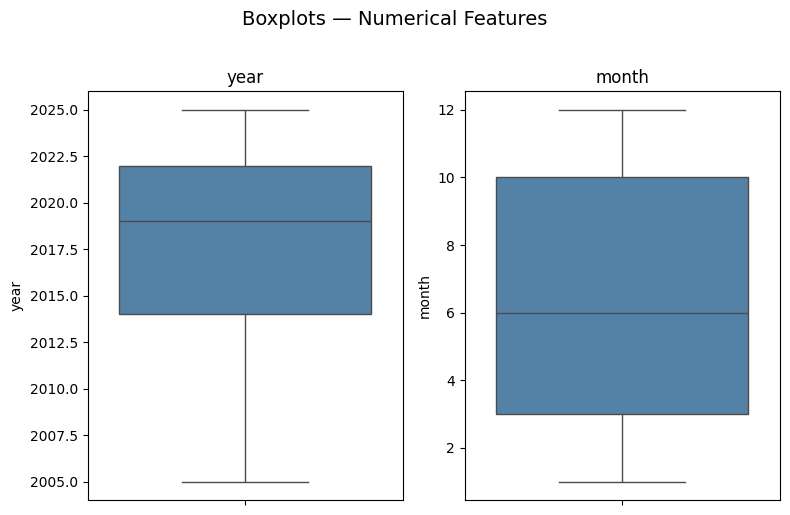


--- IQR Outlier Counts ---
year: 0 outliers (0.0%)
month: 0 outliers (0.0%)


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Outlier Check — Numerical Columns
# ============================================================

numerical_cols = df_enriched.select_dtypes(include='number').columns.tolist()
print("Numerical columns:", numerical_cols)

# Summary stats
print("\n--- Summary Statistics ---")
display(df_enriched[numerical_cols].describe())

# Boxplots for each numerical column
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4 * len(numerical_cols), 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_enriched[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Boxplots — Numerical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# IQR-based Outlier Count per Column
# ============================================================

print("\n--- IQR Outlier Counts ---")
for col in numerical_cols:
    Q1 = df_enriched[col].quantile(0.25)
    Q3 = df_enriched[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_enriched[(df_enriched[col] < Q1 - 1.5 * IQR) | (df_enriched[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_enriched)*100:.1f}%)")

In [15]:
print(df_enriched['notes'].unique())

['First occurrence in a zone or a compartment'
 'Recurrence of an eradicated disease' 'First occurrence in the country'
 'New strain in the country' 'Emerging disease' 'Unusual host species'
 'Recurrence' 'Recurrence of an eradicated strain'
 'New strain in a zone or a compartment'
 'Listed disease occurring in a new host species'
 'Unexpected change or increase'
 'New pathogen strain or disease manifestation' 'Change in epidemiology'
 'New host']


In [16]:
print(df_enriched.isnull().sum())
print()
print(f"Total missing: {df_enriched.isnull().sum().sum()}")

report_id           0
country             0
date_reported       0
species             0
disease             0
outbreak_status     0
notes               0
source              0
iso_code           93
wb_region          93
income_group       93
year                0
month               0
dtype: int64

Total missing: 279


In [17]:
print(df_enriched.select_dtypes(include='number').columns.tolist())

['year', 'month']


In [18]:
dist = df_enriched['notes'].value_counts()
pct = df_enriched['notes'].value_counts(normalize=True) * 100

for label in dist.index:
    print(f"{label}: {dist[label]} ({pct[label]:.1f}%)")

Recurrence of an eradicated disease: 3696 (66.2%)
First occurrence in a zone or a compartment: 779 (14.0%)
First occurrence in the country: 266 (4.8%)
Emerging disease: 197 (3.5%)
New strain in the country: 166 (3.0%)
Recurrence: 143 (2.6%)
New strain in a zone or a compartment: 136 (2.4%)
Recurrence of an eradicated strain: 95 (1.7%)
Unusual host species: 42 (0.8%)
Unexpected change or increase: 37 (0.7%)
Change in epidemiology: 7 (0.1%)
Listed disease occurring in a new host species: 6 (0.1%)
New pathogen strain or disease manifestation: 5 (0.1%)
New host: 4 (0.1%)


## Missing Value Handling

Fill unmatched `wb_region` and `income_group` with `'Unknown'`. These 93 rows represent territories/disputed regions — dropping them would silently remove real outbreak records.

In [19]:
# Fill missing wb_region and income_group with 'Unknown'
# (93 rows where country couldn't be matched to World Bank data)
df_enriched['wb_region'] = df_enriched['wb_region'].fillna('Unknown')
df_enriched['income_group'] = df_enriched['income_group'].fillna('Unknown')

# Drop iso_code — not used as a model feature
if 'iso_code' in df_enriched.columns:
    df_enriched = df_enriched.drop(columns=['iso_code'])

# Drop source, report_id, outbreak_status — constant or identifier columns
drop_cols = [c for c in ['source', 'report_id', 'outbreak_status'] if c in df_enriched.columns]
df_enriched = df_enriched.drop(columns=drop_cols)

print('Missing values after filling:')
print(df_enriched.isnull().sum())
print(f'\nShape: {df_enriched.shape}')
print(f'\nColumns remaining: {df_enriched.columns.tolist()}')

Missing values after filling:
country          0
date_reported    0
species          0
disease          0
notes            0
wb_region        0
income_group     0
year             0
month            0
dtype: int64

Shape: (5579, 9)

Columns remaining: ['country', 'date_reported', 'species', 'disease', 'notes', 'wb_region', 'income_group', 'year', 'month']


## Temporal Train/Test Split

In [20]:
# Temporal train/test split — must happen BEFORE any feature fitting
train_df = df_enriched[df_enriched['year'] <= 2019].copy()
val_df   = df_enriched[(df_enriched['year'] >= 2020) & (df_enriched['year'] <= 2022)].copy()
test_df  = df_enriched[df_enriched['year'] >= 2023].copy()


print(f'Train set: {len(train_df)} rows  ({train_df["year"].min()}–{train_df["year"].max()})')
print(f'Val set:  {len(val_df)} rows  ({val_df["year"].min()}–{val_df["year"].max()})')
print(f'Test set:  {len(test_df)} rows  ({test_df["year"].min()}–{test_df["year"].max()})')


print(f'\nTrain class distribution:')
print(train_df['notes'].value_counts())
print(f'\nVal class distribution:')
print(val_df['notes'].value_counts())
print(f'\nTest class distribution:')
print(test_df['notes'].value_counts())

Train set: 2878 rows  (2005–2019)
Val set:  1325 rows  (2020–2022)
Test set:  1376 rows  (2023–2025)

Train class distribution:
notes
Recurrence of an eradicated disease               1913
First occurrence in a zone or a compartment        475
Emerging disease                                    97
New strain in a zone or a compartment               95
Recurrence                                          83
First occurrence in the country                     83
New strain in the country                           76
Unexpected change or increase                       30
Change in epidemiology                               7
Listed disease occurring in a new host species       6
New pathogen strain or disease manifestation         5
Unusual host species                                 5
New host                                             3
Name: count, dtype: int64

Val class distribution:
notes
Recurrence of an eradicated disease            887
First occurrence in a zone or a compartment

In [21]:

# Function to create short disease label
def create_disease_short(df):
    return df['disease'].str.split('(').str[0].str.strip()

# Apply to train, val, and test sets
train_df['disease_short'] = create_disease_short(train_df)
val_df['disease_short']   = create_disease_short(val_df)
test_df['disease_short']  = create_disease_short(test_df)

## Target Encoding 


In [22]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features to encode
TARGET = 'notes'


# Encode target on training data
le = LabelEncoder()
y_train = le.fit_transform(train_df[TARGET])

# ---------------------------
# Validation set
# ---------------------------
# Keep only labels seen in training
val_mask = val_df[TARGET].isin(le.classes_)
val_df_filtered = val_df[val_mask].copy()
y_val = le.transform(val_df_filtered[TARGET])

# ---------------------------
# Test set
# ---------------------------
# Keep only labels seen in training
test_mask = test_df[TARGET].isin(le.classes_)
test_df_filtered = test_df[test_mask].copy()
y_test = le.transform(test_df_filtered[TARGET])

# Check
print(f"Number of training classes: {len(le.classes_)}")
print(f"Validation set size after filtering: {len(val_df_filtered)}")
print(f"Test set size after filtering: {len(test_df_filtered)}")





Number of training classes: 13
Validation set size after filtering: 1309
Test set size after filtering: 1297


## Feature Encoding 

In [23]:
CATEGORICAL_FEATURES = [
  'country',
  'species',
  'disease_short'
]

NUMERIC_FEATURES = [
    'year',
    'month'
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train = train_df[FEATURE_COLUMNS]
X_val   = val_df_filtered[FEATURE_COLUMNS]
X_test  = test_df_filtered[FEATURE_COLUMNS]

## Preprocessing Pipeline

In [24]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
        ('num', StandardScaler(), NUMERIC_FEATURES)
    ]
)

## DummyClassifier Baseline

Always predicts the majority class. This sets the minimum bar every model must beat.

In [25]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

## Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline_balanced = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

## Decision Tree SMOTE vs NO SMOTE

In [27]:
# Experiment 1: SMOTE vs No SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

dt_no_smote_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [28]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

# K-fold cross validation
k_fold = KFold(n_splits=5, shuffle=True, random_state=1234)
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

dt_no_smote_perf = cross_validate(
    dt_no_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics
)

pd.DataFrame(dt_no_smote_perf).mean()

dt_smote_perf = cross_validate(
    dt_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics
)

pd.DataFrame(dt_smote_perf).mean()

/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/s

fit_time                   0.362124
score_time                 0.012664
test_accuracy              0.657393
test_precision_weighted    0.670659
test_recall_weighted       0.657393
test_f1_weighted           0.662117
test_f1_macro              0.333796
dtype: float64

In [29]:
# Evaluate experiment results
dt_experiment_1_results = pd.DataFrame([
    {
        'pipeline': 'Decision Tree - No SMOTE',
        'mean_accuracy': pd.DataFrame(dt_no_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(dt_no_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(dt_no_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(dt_no_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(dt_no_smote_perf)['test_f1_macro'].mean()
    },
    {
        'pipeline': 'Decision Tree - SMOTE',
        'mean_accuracy': pd.DataFrame(dt_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(dt_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(dt_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(dt_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(dt_smote_perf)['test_f1_macro'].mean()
    }
])

dt_experiment_1_results.sort_values('mean_f1_macro', ascending=False)

,pipeline,mean_accuracy,mean_precision_weighted,mean_recall_weighted,mean_f1_weighted,mean_f1_macro
1,Decision Tree - SMOTE,0.657393,0.670659,0.657393,0.662117,0.333796
0,Decision Tree - No SMOTE,0.690064,0.674681,0.690064,0.679957,0.317607


In [30]:
use_smote_for_dt = (
    pd.DataFrame(dt_smote_perf)['test_f1_macro'].mean() >
    pd.DataFrame(dt_no_smote_perf)['test_f1_macro'].mean()
)

print('Use SMOTE for Decision Tree?', use_smote_for_dt)

# Set dt_pipeline to whichever performed better
dt_pipeline = dt_smote_pipeline if use_smote_for_dt else dt_no_smote_pipeline

Use SMOTE for Decision Tree? True


## Fit and Evaluate Models (No Tuning)

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w      = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score (Weighted) : {f1_w:.4f}")
    print(f"F1-score (Macro) : {f1:.4f}")


# Train + evaluate
evaluate_model(
    "Dummy Classifier",
    dummy_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Decision Tree",
    dt_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)




=== Dummy Classifier ===
Accuracy : 0.6776
Precision: 0.4592
Recall   : 0.6776
F1-score (Weighted) : 0.5474
F1-score (Macro) : 0.0898

=== Decision Tree ===
Accuracy : 0.5462
Precision: 0.6393
Recall   : 0.5462
F1-score (Weighted) : 0.5692
F1-score (Macro) : 0.2386


## Decision Tree Pipeline (Hyperparameter Tuning)

In [32]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate


k_fold = KFold(n_splits=5, shuffle=True, random_state=1234)
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

dt_perf = cross_validate(dt_pipeline, X_train, y_train, cv=k_fold, scoring=scoring_metrics)

pd.DataFrame(dt_perf).mean()

/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/m

fit_time                   0.350397
score_time                 0.012064
test_accuracy              0.657393
test_precision_weighted    0.670659
test_recall_weighted       0.657393
test_f1_weighted           0.662117
test_f1_macro              0.333796
dtype: float64

In [33]:
dt_step_name = dt_pipeline.steps[2][0]
step_prefix = '__'
dt_step_prefix = f"{dt_step_name}{step_prefix}"
dt_step_prefix

'classifier__'

In [34]:
dt_max_depth_key = dt_step_prefix + 'max_depth'
alpha_key = dt_step_prefix + 'ccp_alpha'
criterion_key = dt_step_prefix + 'criterion'

In [35]:
from sklearn.model_selection import GridSearchCV

def explore_single_hp_values(pipeline, param_name, param_values, X_train, y_train, k_fold, scoring):
    param_grid = {param_name: param_values}
    grid_search = GridSearchCV(pipeline, param_grid, cv=k_fold, scoring=scoring)
    grid_search.fit(X_train, y_train)
    result_columns = [f"param_{param_name}", "mean_test_score", "std_test_score", "rank_test_score"]
    return pd.DataFrame(grid_search.cv_results_)[result_columns]



In [36]:
explore_single_hp_values(dt_pipeline, dt_max_depth_key, [50, 51, 52, 53, 54], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__max_depth,mean_test_score,std_test_score,rank_test_score
0,50,0.333263,0.054561,3
1,51,0.331536,0.047222,4
2,52,0.327284,0.039470,5
3,53,0.340003,0.040801,2
4,54,0.346942,0.052780,1


In [37]:
explore_single_hp_values(dt_pipeline, alpha_key, [0.0, 0.001, 0.002, 0.003], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__ccp_alpha,mean_test_score,std_test_score,rank_test_score
0,0.000,0.333796,0.026910,1
1,0.001,0.266675,0.033867,2
2,0.002,0.239688,0.035460,3
3,0.003,0.203401,0.037480,4


In [38]:
dt_param_grid = {dt_max_depth_key : [50, 51, 52, 53, 54],
                 alpha_key : [0.0, 0.001, 0.002, 0.003],
                 criterion_key : ['gini', 'entropy', 'log_loss']}
grid_search_dt = GridSearchCV(dt_pipeline, dt_param_grid, cv=k_fold, scoring='f1_macro')
grid_search_dt.fit(X_train, y_train)

grid_search_dt.best_params_

{'classifier__ccp_alpha': 0.0,
 'classifier__criterion': 'gini',
 'classifier__max_depth': 54}

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_gridsearch_heatmap(results_df, x_param, y_param, score='mean_test_score'):    
    # Pivot the table to format it for a heatmap
    heatmap_data = results_df.pivot(index=f'param_{y_param}', columns=f'param_{x_param}', values=score)
    
    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f', linewidths=0.5)
    plt.title(f'Grid Search Results: {score}')
    plt.xlabel(x_param)
    plt.ylabel(y_param)
    plt.show()

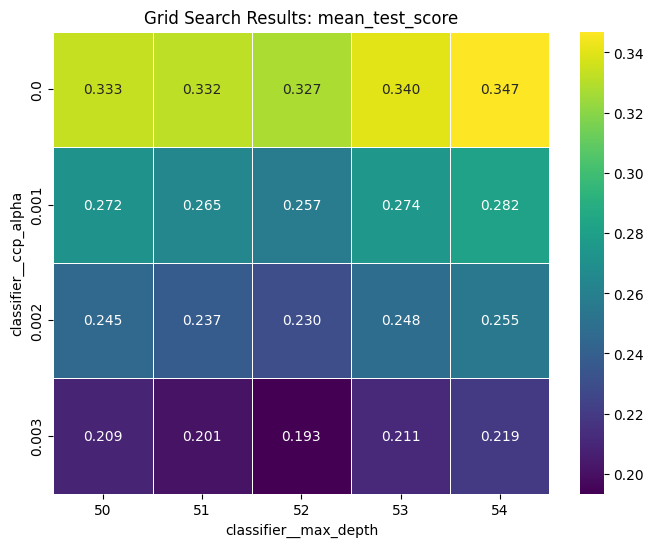

In [40]:
results = pd.DataFrame(grid_search_dt.cv_results_)
results = results[results['param_' + criterion_key] == 'gini']
plot_gridsearch_heatmap(results, dt_max_depth_key, alpha_key)

## Re-Evaluate DT vs DT Tuned vs Baseline

In [41]:
evaluate_model(
    "Dummy Classifier",
    dummy_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Decision Tree",
    dt_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Decision Tree (Tuned)",
    grid_search_dt,
    X_train,
    y_train,
    X_val,
    y_val
)


=== Dummy Classifier ===
Accuracy : 0.6776
Precision: 0.4592
Recall   : 0.6776
F1-score (Weighted) : 0.5474
F1-score (Macro) : 0.0898

=== Decision Tree ===
Accuracy : 0.5462
Precision: 0.6393
Recall   : 0.5462
F1-score (Weighted) : 0.5692
F1-score (Macro) : 0.2386

=== Decision Tree (Tuned) ===
Accuracy : 0.5348
Precision: 0.6417
Recall   : 0.5348
F1-score (Weighted) : 0.5613
F1-score (Macro) : 0.2101


## Random Forest

In [42]:
# imports
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [43]:
# Experiment 1: SMOTE vs No SMOTE
rf_no_smote_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [44]:
# K-fold cross validation
k_fold = KFold(n_splits=5, shuffle=True, random_state=1234)
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

rf_no_smote_perf = cross_validate(
    rf_no_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics
)

pd.DataFrame(rf_no_smote_perf).mean()

rf_smote_perf = cross_validate(
    rf_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics
)

pd.DataFrame(rf_smote_perf).mean()

/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/s

fit_time                   1.283020
score_time                 0.050621
test_accuracy              0.718897
test_precision_weighted    0.672886
test_recall_weighted       0.718897
test_f1_weighted           0.687349
test_f1_macro              0.322585
dtype: float64

In [45]:
# Evaluate experiment results
rf_experiment_1_results = pd.DataFrame([
    {
        'pipeline': 'Random Forest - No SMOTE',
        'mean_accuracy': pd.DataFrame(rf_no_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(rf_no_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(rf_no_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(rf_no_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(rf_no_smote_perf)['test_f1_macro'].mean()
    },
    {
        'pipeline': 'Random Forest - SMOTE',
        'mean_accuracy': pd.DataFrame(rf_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(rf_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(rf_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(rf_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(rf_smote_perf)['test_f1_macro'].mean()
    }
])

rf_experiment_1_results.sort_values('mean_f1_macro', ascending=False)

,pipeline,mean_accuracy,mean_precision_weighted,mean_recall_weighted,mean_f1_weighted,mean_f1_macro
1,Random Forest - SMOTE,0.718897,0.672886,0.718897,0.687349,0.322585
0,Random Forest - No SMOTE,0.730366,0.674977,0.730366,0.688532,0.312304


In [46]:
use_smote_for_rf = (
    pd.DataFrame(rf_smote_perf)['test_f1_macro'].mean() >
    pd.DataFrame(rf_no_smote_perf)['test_f1_macro'].mean()
)

print('Use SMOTE for Random Forest?', use_smote_for_rf)

Use SMOTE for Random Forest? True


In [47]:
rf_pipeline = rf_no_smote_pipeline

In [48]:
# Random Forest Hyperparameter Tuning
rf_n_estimators_key = 'classifier__n_estimators'
rf_max_depth_key = 'classifier__max_depth'
rf_max_features_key = 'classifier__max_features'
rf_class_weight_key = 'classifier__class_weight'

In [49]:
# Initial grid values from design document for n-estimators
explore_single_hp_values(rf_pipeline, rf_n_estimators_key, [50, 100, 200], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__n_estimators,mean_test_score,std_test_score,rank_test_score
0,50,0.314129,0.054778,1
1,100,0.312304,0.047963,2
2,200,0.311841,0.053917,3


In [50]:
# Improved n-estimator values
explore_single_hp_values(rf_pipeline, rf_n_estimators_key, [55, 60, 65], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__n_estimators,mean_test_score,std_test_score,rank_test_score
0,55,0.312096,0.052407,2
1,60,0.314318,0.054980,1
2,65,0.311452,0.056318,3


In [51]:
# Initial grid values from design document for max depth
explore_single_hp_values(rf_pipeline, rf_max_depth_key, [3, 5, 10], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__max_depth,mean_test_score,std_test_score,rank_test_score
0,3,0.070856,0.007785,2
1,5,0.070856,0.007785,2
2,10,0.121510,0.027568,1


In [52]:
# Improved max depth values
explore_single_hp_values(rf_pipeline, rf_max_depth_key, [80, 100, 120], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__max_depth,mean_test_score,std_test_score,rank_test_score
0,80,0.308844,0.049276,2
1,100,0.306257,0.048580,3
2,120,0.312344,0.048187,1


In [53]:
rf_param_grid = {
    rf_n_estimators_key: [50, 60, 70],
    rf_max_depth_key: [80, 100, 120],
    rf_max_features_key: ['sqrt', 'log2'],
    rf_class_weight_key: [None, 'balanced']
}

grid_search_rf = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=k_fold,
    scoring='f1_macro'
)

grid_search_rf.fit(X_train, y_train)

grid_search_rf.best_params_

{'classifier__class_weight': None,
 'classifier__max_depth': 80,
 'classifier__max_features': 'sqrt',
 'classifier__n_estimators': 50}

In [54]:
grid_search_rf.best_score_

rf_results = pd.DataFrame(grid_search_rf.cv_results_)
rf_results.sort_values('mean_test_score', ascending=False).head(10)

evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Random Forest (Tuned)",
    grid_search_rf,
    X_train,
    y_train,
    X_val,
    y_val
)


=== Random Forest ===
Accuracy : 0.6257
Precision: 0.5786
Recall   : 0.6257
F1-score (Weighted) : 0.5801
F1-score (Macro) : 0.2167


/opt/tljh/user/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



=== Random Forest (Tuned) ===
Accuracy : 0.6325
Precision: 0.5769
Recall   : 0.6325
F1-score (Weighted) : 0.5821
F1-score (Macro) : 0.2005


## AdaBoost

In [55]:
#Imports
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, KFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [56]:
k_fold = KFold(n_splits=5, shuffle=True, random_state=1234)
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

In [57]:
#SMOTE vs. no SMOTE 
# AdaBoost - No SMOTE
ada_no_smote_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

ada_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

In [58]:
# 5-fold CV for SMOTE vs. no SMOTE 
ada_no_smote_perf = cross_validate(
    ada_no_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics,
    n_jobs=-1
)

ada_smote_perf = cross_validate(
    ada_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics,
    n_jobs=-1
)

/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tlj

In [59]:
# Create Table 
ada_experiment_1_results = pd.DataFrame([
    {
        'pipeline': 'AdaBoost - No SMOTE',
        'mean_accuracy': pd.DataFrame(ada_no_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(ada_no_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(ada_no_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(ada_no_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(ada_no_smote_perf)['test_f1_macro'].mean()
    },
    {
        'pipeline': 'AdaBoost - SMOTE',
        'mean_accuracy': pd.DataFrame(ada_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(ada_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(ada_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(ada_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(ada_smote_perf)['test_f1_macro'].mean()
    }
])

display(ada_experiment_1_results.sort_values('mean_f1_macro', ascending=False))

use_smote_for_ada = (
    pd.DataFrame(ada_smote_perf)['test_f1_macro'].mean() >
    pd.DataFrame(ada_no_smote_perf)['test_f1_macro'].mean()
)

print("Use SMOTE for AdaBoost:", use_smote_for_ada)

,pipeline,mean_accuracy,mean_precision_weighted,mean_recall_weighted,mean_f1_weighted,mean_f1_macro
1,AdaBoost - SMOTE,0.664339,0.674304,0.664339,0.667419,0.323876
0,AdaBoost - No SMOTE,0.690060,0.666745,0.690060,0.674270,0.320723


Use SMOTE for AdaBoost: True


In [60]:
# Moves best performer on 
if use_smote_for_ada:
    ada_pipeline = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=1)),
        ('classifier', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ))
    ])
else:
    ada_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('classifier', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ))
    ])

In [61]:
#Grid Paratmeter Names

ada_param_grid = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__estimator__max_depth': [1, 2]
}


In [62]:
grid_search_ada = GridSearchCV(
    ada_pipeline,
    ada_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_ada.fit(X_train, y_train)

print("Best Params:", grid_search_ada.best_params_)
print("Best CV F1-macro:", grid_search_ada.best_score_)

/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Fitting 5 folds for each of 32 candidates, totalling 160 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tlj

Best Params: {'classifier__estimator__max_depth': 2, 'classifier__learning_rate': 0.2, 'classifier__n_estimators': 300}
Best CV F1-macro: 0.16033964844117085


In [63]:
ada_results = pd.DataFrame(grid_search_ada.cv_results_)
display(
    ada_results.sort_values('mean_test_score', ascending=False)[[
        'param_classifier__n_estimators',
        'param_classifier__learning_rate',
        'param_classifier__estimator__max_depth',
        'mean_test_score',
        'std_test_score',
        'rank_test_score'
    ]].head(10)
)

,param_classifier__n_estimators,param_classifier__learning_rate,param_classifier__estimator__max_depth,mean_test_score,std_test_score,rank_test_score
31,300,0.20,2,0.160340,0.019854,1
28,50,0.20,2,0.156455,0.052197,2
22,200,0.05,2,0.151659,0.040273,3
30,200,0.20,2,0.150736,0.026234,4
29,100,0.20,2,0.150371,0.031062,5
23,300,0.05,2,0.150194,0.041101,6
27,300,0.10,2,0.149937,0.034859,7
25,100,0.10,2,0.148872,0.030939,8
24,50,0.10,2,0.144779,0.025090,9
20,50,0.05,2,0.137207,0.032764,10


In [64]:
#AdaBoost Selection
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_adaboost_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"F1-weighted : {f1_weighted:.4f}")
    print(f"F1-macro    : {f1_macro:.4f}")

In [65]:
#Evaluation

ada_pipeline.fit(X_train, y_train)

evaluate_adaboost_model(
    "AdaBoost",
    ada_pipeline,
    X_val,
    y_val
)

evaluate_adaboost_model(
    "AdaBoost (Tuned)",
    grid_search_ada,
    X_val,
    y_val
)

/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



=== AdaBoost ===
Accuracy    : 0.5913
Precision   : 0.6453
Recall      : 0.5913
F1-weighted : 0.5989
F1-macro    : 0.2576

=== AdaBoost (Tuned) ===
Accuracy    : 0.6211
Precision   : 0.6359
Recall      : 0.6211
F1-weighted : 0.5871
F1-macro    : 0.1955


## Logistic Regression

In [66]:
# ============================================================
# Logistic Regression
# ============================================================
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline


# --- Experiment 1: SMOTE vs No SMOTE ---
lr_no_smote_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=5000, n_jobs=-1))
])

lr_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('classifier', LogisticRegression(random_state=42, max_iter=5000, n_jobs=-1))
])

lr_no_smote_perf = cross_validate(
    lr_no_smote_pipeline, X_train, y_train,
    cv=k_fold, scoring=scoring_metrics
)

lr_smote_perf = cross_validate(
    lr_smote_pipeline, X_train, y_train,
    cv=k_fold, scoring=scoring_metrics
)

# --- Compare results ---
lr_experiment_1_results = pd.DataFrame([
    {
        'pipeline': 'Logistic Regression - No SMOTE',
        'mean_accuracy':              pd.DataFrame(lr_no_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted':    pd.DataFrame(lr_no_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted':       pd.DataFrame(lr_no_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted':           pd.DataFrame(lr_no_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro':              pd.DataFrame(lr_no_smote_perf)['test_f1_macro'].mean()
    },
    {
        'pipeline': 'Logistic Regression - SMOTE',
        'mean_accuracy':              pd.DataFrame(lr_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted':    pd.DataFrame(lr_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted':       pd.DataFrame(lr_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted':           pd.DataFrame(lr_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro':              pd.DataFrame(lr_smote_perf)['test_f1_macro'].mean()
    }
])

display(lr_experiment_1_results.sort_values('mean_f1_macro', ascending=False))

use_smote_for_lr = (
    pd.DataFrame(lr_smote_perf)['test_f1_macro'].mean() >
    pd.DataFrame(lr_no_smote_perf)['test_f1_macro'].mean()
)
print('Use SMOTE for Logistic Regression?', use_smote_for_lr)

# Set best pipeline
lr_pipeline = lr_smote_pipeline if use_smote_for_lr else lr_no_smote_pipeline

/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-pa

,pipeline,mean_accuracy,mean_precision_weighted,mean_recall_weighted,mean_f1_weighted,mean_f1_macro
1,Logistic Regression - SMOTE,0.529886,0.680543,0.529886,0.574860,0.329802
0,Logistic Regression - No SMOTE,0.725857,0.671677,0.725857,0.675134,0.269766


Use SMOTE for Logistic Regression? True


While SMOTE performs better in f1_macro model does not converge with 5000 iterations so model without smote will be used.

In [67]:
# --- Hyperparameter Tuning ---
# Logistic Regression key hyperparameters:
#   C           — inverse regularization strength (smaller = stronger regularization)
#   penalty     — l1 (sparse) or l2 (default); l1 requires solver='saga'
#   class_weight — None or 'balanced'

lr_param_grid = {
    'classifier__C':            [0.05, 0.06, 0.07, 0.08],
    'classifier__penalty':      ['l2'],         
    'classifier__class_weight': ['balanced']
}

grid_search_lr = GridSearchCV(
    lr_no_smote_pipeline,
    lr_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train, y_train)

print("Best Params:", grid_search_lr.best_params_)
print("Best CV F1-macro:", grid_search_lr.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'classifier__C': 0.08, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
Best CV F1-macro: 0.21483771562854187


In [68]:
# --- Evaluate on validation set ---
evaluate_model(
    "Logistic Regression",
    lr_no_smote_pipeline,
    X_train, 
    y_train,
    X_val, 
    y_val
)

evaluate_model(
    "Logistic Regression (Tuned)",
    grid_search_lr,
    X_train, 
    y_train,
    X_val, 
    y_val
)


=== Logistic Regression ===
Accuracy : 0.5340
Precision: 0.6384
Recall   : 0.5340
F1-score (Weighted) : 0.5433
F1-score (Macro) : 0.2122
Fitting 5 folds for each of 4 candidates, totalling 20 fits

=== Logistic Regression (Tuned) ===
Accuracy : 0.0871
Precision: 0.0334
Recall   : 0.0871
F1-score (Weighted) : 0.0256
F1-score (Macro) : 0.0731


## Support Vector Machine (LinearSVC one-versus-rest)

In [69]:
from sklearn.svm import LinearSVC

svm_no_smote_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(random_state=42, class_weight='balanced'))
])

svm_smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('SMOTE', SMOTE(random_state=42, k_neighbors=1)),
    ('classifier', LinearSVC(random_state=42, class_weight='balanced'))
])

svm_no_smote_perf = cross_validate(
    svm_no_smote_pipeline, X_train, y_train,
    cv=k_fold, scoring=scoring_metrics
)

svm_smote_perf = cross_validate(
    svm_smote_pipeline, X_train, y_train,
    cv=k_fold, scoring=scoring_metrics
)

# --- Compare results ---
svm_experiment_1_results = pd.DataFrame([
    {
        'pipeline': 'SVM - No SMOTE',
        'mean_accuracy':              pd.DataFrame(svm_no_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted':    pd.DataFrame(svm_no_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted':       pd.DataFrame(svm_no_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted':           pd.DataFrame(svm_no_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro':              pd.DataFrame(svm_no_smote_perf)['test_f1_macro'].mean()
    },
    {
        'pipeline': 'SVM - SMOTE',
        'mean_accuracy':              pd.DataFrame(svm_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted':    pd.DataFrame(svm_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted':       pd.DataFrame(svm_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted':           pd.DataFrame(svm_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro':              pd.DataFrame(svm_smote_perf)['test_f1_macro'].mean()
    }
])

display(svm_experiment_1_results.sort_values('mean_f1_macro', ascending=False))

use_smote_for_svm = (
    pd.DataFrame(svm_smote_perf)['test_f1_macro'].mean() >
    pd.DataFrame(svm_no_smote_perf)['test_f1_macro'].mean()
)
print('Use SMOTE for SVM?', use_smote_for_svm)

# Set best pipeline
svm_pipeline = svm_smote_pipeline if use_smote_for_svm else svm_no_smote_pipeline


/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/tljh/user/lib/python3.12/site-packages/sklearn/m

,pipeline,mean_accuracy,mean_precision_weighted,mean_recall_weighted,mean_f1_weighted,mean_f1_macro
0,SVM - No SMOTE,0.626133,0.684185,0.626133,0.648871,0.330789
1,SVM - SMOTE,0.520851,0.677716,0.520851,0.567229,0.316783


Use SMOTE for SVM? False


In [70]:
explore_single_hp_values(svm_pipeline, 'classifier__C', [1, 10, 100, 1000], X_train, y_train, k_fold, 'f1_macro')

/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the n

,param_classifier__C,mean_test_score,std_test_score,rank_test_score
0,1,0.330789,0.026765,3
1,10,0.333934,0.030798,1
2,100,0.331841,0.023374,2
3,1000,0.325799,0.020833,4


In [71]:
svm_param_grid = {
    'classifier__C': [1, 10, 100, 1000],
}

grid_search_svm = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search_svm.fit(X_train, y_train)

print("Best Params:", grid_search_svm.best_params_)
print("Best CV F1-macro:", grid_search_svm.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the n

Best Params: {'classifier__C': 10}
Best CV F1-macro: 0.3339342992101914


/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [72]:
evaluate_model(
    "SVM",
    svm_pipeline,
    X_train, 
    y_train,
    X_val, 
    y_val
)

evaluate_model(
    "SVM (Tuned)",
    grid_search_svm,
    X_train, 
    y_train,
    X_val, 
    y_val
)


=== SVM ===
Accuracy : 0.2529
Precision: 0.6599
Recall   : 0.2529
F1-score (Weighted) : 0.3072
F1-score (Macro) : 0.1518
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the n


=== SVM (Tuned) ===
Accuracy : 0.2338
Precision: 0.6360
Recall   : 0.2338
F1-score (Weighted) : 0.2873
F1-score (Macro) : 0.1531


/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Feature Selection DT

In [73]:
from sklearn.feature_selection import SelectKBest, f_classif, SelectPercentile, SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

dt_kbest_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif, percentile=15)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

evaluate_model(
    "Decision Tree",
    dt_kbest_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)



=== Decision Tree ===
Accuracy : 0.6707
Precision: 0.5701
Recall   : 0.6707
F1-score (Weighted) : 0.5862
F1-score (Macro) : 0.2163


In [74]:
kbest_param_grid = {
    'selector__percentile':     [5, 10, 15, 20, 25, 100],
    'classifier__max_depth':    [50, 51, 52, 53, 54],
    'classifier__criterion':    ['gini', 'entropy'],
    'classifier__ccp_alpha':    [0.0, 0.001, 0.002, 0.003]
}

grid_search_dt_kbest = GridSearchCV(
    dt_kbest_pipeline,
    kbest_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search_dt_kbest.fit(X_train, y_train)
print("Best params (KBest):", grid_search_dt_kbest.best_params_)
print("Best CV F1-macro:   ", grid_search_dt_kbest.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best params (KBest): {'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'gini', 'classifier__max_depth': 54, 'selector__percentile': 100}
Best CV F1-macro:    0.3305305156046066


In [75]:
evaluate_model(
    "Decision Tree + FS (Tuned)",
    grid_search_dt_kbest,
    X_train,
    y_train,
    X_val,
    y_val
)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

=== Decision Tree + FS (Tuned) ===
Accuracy : 0.5584
Precision: 0.5790
Recall   : 0.5584
F1-score (Weighted) : 0.5540
F1-score (Macro) : 0.2249


/opt/tljh/user/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


## Feature Selection Random Forest

In [76]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

rf_feature_selection_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('selector', SelectFromModel(
        estimator=RandomForestClassifier(
            n_estimators=60,
            max_depth=100,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ),
        threshold='median'
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_model(
    "Random Forest + Feature Selection",
    rf_feature_selection_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)


=== Random Forest + Feature Selection ===
Accuracy : 0.6264
Precision: 0.5804
Recall   : 0.6264
F1-score (Weighted) : 0.5831
F1-score (Macro) : 0.2167


In [77]:
rf_feature_selection_param_grid = {
    'selector__threshold': ['mean', 'median'],
    'classifier__n_estimators': [50, 60, 70],
    'classifier__max_depth': [80, 100, 120],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': [None, 'balanced']
}

grid_search_rf_feature_selection = GridSearchCV(
    rf_feature_selection_pipeline,
    rf_feature_selection_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_rf_feature_selection.fit(X_train, y_train)

print("Best params (Random Forest + Feature Selection):", grid_search_rf_feature_selection.best_params_)
print("Best CV F1-macro:", grid_search_rf_feature_selection.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params (Random Forest + Feature Selection): {'classifier__class_weight': None, 'classifier__max_depth': 100, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
Best CV F1-macro: 0.32134888003441353


In [78]:
evaluate_model(
    "Random Forest + Feature Selection (Tuned)",
    grid_search_rf_feature_selection,
    X_train,
    y_train,
    X_val,
    y_val
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Random Forest + Feature Selection (Tuned) ===
Accuracy : 0.6218
Precision: 0.5806
Recall   : 0.6218
F1-score (Weighted) : 0.5815
F1-score (Macro) : 0.2126


In [79]:
rf_feature_selection_results = pd.DataFrame(grid_search_rf_feature_selection.cv_results_)

rf_feature_selection_results.sort_values(
    'mean_test_score',
    ascending=False
).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__class_weight,param_classifier__max_depth,param_classifier__max_features,param_classifier__n_estimators,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,0.633718,0.038248,0.102938,0.033384,None,100,sqrt,50,median,"{'classifier__class_weight': None, 'classifier...",0.277331,0.264564,0.431370,0.337115,0.296364,0.321349,0.060232,1
25,0.638689,0.019622,0.107297,0.021909,None,120,sqrt,50,median,"{'classifier__class_weight': None, 'classifier...",0.277331,0.264870,0.430455,0.337115,0.293989,0.320752,0.060045,2
1,0.658819,0.053102,0.098136,0.012087,None,80,sqrt,50,median,"{'classifier__class_weight': None, 'classifier...",0.270474,0.266157,0.428879,0.338545,0.295291,0.319869,0.060267,3
3,0.665135,0.043968,0.096247,0.021483,None,80,sqrt,60,median,"{'classifier__class_weight': None, 'classifier...",0.268281,0.268236,0.425898,0.334485,0.295456,0.318471,0.058939,4
43,0.666419,0.020555,0.097507,0.020209,balanced,80,log2,50,median,"{'classifier__class_weight': 'balanced', 'clas...",0.313772,0.252251,0.401547,0.313799,0.297342,0.315742,0.048456,5
19,0.665549,0.062782,0.089302,0.007481,None,100,log2,50,median,"{'classifier__class_weight': None, 'classifier...",0.273023,0.262979,0.388846,0.336715,0.315643,0.315441,0.045591,6
31,0.643458,0.046225,0.103854,0.016642,None,120,log2,50,median,"{'classifier__class_weight': None, 'classifier...",0.263153,0.262979,0.398830,0.331627,0.319590,0.315236,0.050436,7
17,0.763479,0.026206,0.096518,0.018753,None,100,sqrt,70,median,"{'classifier__class_weight': None, 'classifier...",0.277671,0.264468,0.396135,0.335457,0.301090,0.314964,0.047205,8
29,0.792491,0.053971,0.122942,0.008766,None,120,sqrt,70,median,"{'classifier__class_weight': None, 'classifier...",0.277671,0.264027,0.396135,0.335457,0.300059,0.314670,0.047362,9
67,0.716671,0.030001,0.071771,0.014246,balanced,120,log2,50,median,"{'classifier__class_weight': 'balanced', 'clas...",0.314905,0.255127,0.394889,0.309452,0.298396,0.314554,0.045327,10


## Feature Selection AdaBoost

In [80]:
## Feature Selection AdaBoost

from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Use SMOTE if AdaBoost SMOTE was better earlier
ada_fs_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('selector', SelectPercentile(score_func=f_classif)),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

In [81]:
evaluate_model(
    "AdaBoost + Feature Selection",
    ada_fs_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



=== AdaBoost + Feature Selection ===
Accuracy : 0.4843
Precision: 0.4949
Recall   : 0.4843
F1-score (Weighted) : 0.4868
F1-score (Macro) : 0.1110


In [82]:
ada_fs_param_grid = {
    'selector__percentile': [10, 15, 20, 25, 30],
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__estimator__max_depth': [1, 2]
}

grid_search_ada_fs = GridSearchCV(
    ada_fs_pipeline,
    ada_fs_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_ada_fs.fit(X_train, y_train)

print("Best Params:", grid_search_ada_fs.best_params_)
print("Best CV F1-macro:", grid_search_ada_fs.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tlj

Best Params: {'classifier__estimator__max_depth': 2, 'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50, 'selector__percentile': 30}
Best CV F1-macro: 0.1657005647700703


In [83]:
evaluate_model(
    "AdaBoost + Feature Selection (Tuned)",
    grid_search_ada_fs,
    X_train,
    y_train,
    X_val,
    y_val
)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tlj


=== AdaBoost + Feature Selection (Tuned) ===
Accuracy : 0.1222
Precision: 0.5331
Recall   : 0.1222
F1-score (Weighted) : 0.1190
F1-score (Macro) : 0.0540


## Feature Selection Logistic Regression

In [84]:
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_kbest_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif, percentile=15)),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=20000,
        solver='lbfgs'
    ))
])

evaluate_model(
    "Logistic Regression + Feature Selection",
    lr_kbest_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)


=== Logistic Regression + Feature Selection ===
Accuracy : 0.5225
Precision: 0.5954
Recall   : 0.5225
F1-score (Weighted) : 0.5090
F1-score (Macro) : 0.1587


In [85]:
lr_kbest_param_grid = {
    'selector__percentile':     [5, 10, 15, 20, 25, 100],
    'classifier__C':            [0.01, 0.05, 0.1, 0.5, 1.0],
    'classifier__penalty':      ['l2'],
    'classifier__class_weight': ['balanced']
}

grid_search_lr_kbest = GridSearchCV(
    lr_kbest_pipeline,
    lr_kbest_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_lr_kbest.fit(X_train, y_train)

print("Best params (LR + KBest):", grid_search_lr_kbest.best_params_)
print("Best CV F1-macro:        ", grid_search_lr_kbest.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (LR + KBest): {'classifier__C': 1.0, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'selector__percentile': 100}
Best CV F1-macro:         0.3022144898886857


In [86]:
evaluate_model(
    "Logistic Regression + Feature Selection (Tuned)",
    grid_search_lr_kbest,
    X_train,
    y_train,
    X_val,
    y_val
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== Logistic Regression + Feature Selection (Tuned) ===
Accuracy : 0.1283
Precision: 0.6387
Recall   : 0.1283
F1-score (Weighted) : 0.1039
F1-score (Macro) : 0.1081


## SVM Feature Selection

In [87]:
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

svm_kbest_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif, percentile=15)),
    ('classifier', LinearSVC(
        random_state=42,
        max_iter=20000
    ))
])

evaluate_model(
    "SVM + Feature Selection",
    svm_kbest_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)


=== SVM + Feature Selection ===
Accuracy : 0.6875
Precision: 0.5662
Recall   : 0.6875
F1-score (Weighted) : 0.5899
F1-score (Macro) : 0.1773


In [88]:
from sklearn.model_selection import GridSearchCV

svm_kbest_param_grid = {
    'selector__percentile': [5, 10, 15, 20, 25, 100],
    'classifier__C':        [0.01, 0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid_search_svm_kbest = GridSearchCV(
    svm_kbest_pipeline,
    svm_kbest_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_svm_kbest.fit(X_train, y_train)

print("Best params (SVM + KBest):", grid_search_svm_kbest.best_params_)
print("Best CV F1-macro:         ", grid_search_svm_kbest.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params (SVM + KBest): {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'selector__percentile': 100}
Best CV F1-macro:          0.3339342992101914


In [89]:
evaluate_model(
    "SVM + Feature Selection (Tuned)",
    grid_search_svm_kbest,
    X_train,
    y_train,
    X_val,
    y_val
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== SVM + Feature Selection (Tuned) ===
Accuracy : 0.2338
Precision: 0.6360
Recall   : 0.2338
F1-score (Weighted) : 0.2873
F1-score (Macro) : 0.1531


## Final Evaluation

In [90]:
X_train_full = pd.concat([X_train, X_val], axis=0)
X_train_full

,year,month,country,species,disease_short
400,2006,11,Israel,Unknown,Bluetongue virus
401,2006,11,Latvia,Poultry,Newcastle disease virus
402,2006,11,United Kingdom,Poultry,Newcastle disease virus
403,2006,11,Germany,Swine,Classical swine fever virus
404,2006,11,Botswana,Cattle,Foot and mouth disease virus
...,...,...,...,...,...
5574,2022,12,Ireland,Poultry,Influenza A viruses of high pathogenicity
5575,2022,12,Russia,Poultry,Influenza A viruses of high pathogenicity
5576,2022,12,Russia,Unknown,Lumpy skin disease virus
5577,2022,12,Ireland,Poultry,High pathogenicity avian influenza viruses


In [91]:
import numpy as np

y_train_full = np.concatenate([y_train, y_val])
y_train_full

array([10,  2, 10, ..., 10, 10,  1], shape=(4187,))

Dummy Final Eval

In [92]:
evaluate_model(
    "Dummy Classifier",
    dummy_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)


=== Dummy Classifier ===
Accuracy : 0.6908
Precision: 0.4772
Recall   : 0.6908
F1-score (Weighted) : 0.5645
F1-score (Macro) : 0.0817


DT Final Eval

In [93]:

evaluate_model(
    "Decision Tree",
    dt_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "Decision Tree (Tuned)",
    grid_search_dt,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

# Featute Selection

evaluate_model(
    "Decision Tree + FS",
    dt_kbest_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "Decision Tree + FS (Tuned)",
    grid_search_dt_kbest,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)


=== Decision Tree ===
Accuracy : 0.6307
Precision: 0.6214
Recall   : 0.6307
F1-score (Weighted) : 0.6228
F1-score (Macro) : 0.3408


/opt/tljh/user/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
60 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/tljh/user/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/tljh/user/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/tljh/user/lib/python3.12/site-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(


=== Decision Tree (Tuned) ===
Accuracy : 0.6160
Precision: 0.6255
Recall   : 0.6160
F1-score (Weighted) : 0.6173
F1-score (Macro) : 0.3372

=== Decision Tree + FS ===
Accuracy : 0.6993
Precision: 0.6084
Recall   : 0.6993
F1-score (Weighted) : 0.6249
F1-score (Macro) : 0.2684
Fitting 5 folds for each of 240 candidates, totalling 1200 fits

=== Decision Tree + FS (Tuned) ===
Accuracy : 0.6330
Precision: 0.6076
Recall   : 0.6330
F1-score (Weighted) : 0.6153
F1-score (Macro) : 0.2814


/opt/tljh/user/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
from sklearn.metrics import classification_report

y_pred = grid_search_dt.predict(X_test)

labels = sorted(set(y_test) | set(y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=[le.classes_[i] for i in labels]
))

Random Forest Final Eval

In [94]:
evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "Random Forest (Tuned)",
    grid_search_rf,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "Random Forest + Feature Selection",
    rf_feature_selection_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "Random Forest + Feature Selection (Tuned)",
    grid_search_rf_feature_selection,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)


=== Random Forest ===
Accuracy : 0.6947
Precision: 0.6162
Recall   : 0.6947
F1-score (Weighted) : 0.6403
F1-score (Macro) : 0.3078

=== Random Forest (Tuned) ===
Accuracy : 0.6847
Precision: 0.6100
Recall   : 0.6847
F1-score (Weighted) : 0.6339
F1-score (Macro) : 0.3072

=== Random Forest + Feature Selection ===
Accuracy : 0.6762
Precision: 0.6181
Recall   : 0.6762
F1-score (Weighted) : 0.6363
F1-score (Macro) : 0.3115
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Random Forest + Feature Selection (Tuned) ===
Accuracy : 0.6608
Precision: 0.6050
Recall   : 0.6608
F1-score (Weighted) : 0.6254
F1-score (Macro) : 0.2974


In [ ]:
y_pred = rf_pipeline.predict(X_test)

labels = sorted(set(y_test) | set(y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=[le.classes_[i] for i in labels]
))

AdaBoost Final Eval

In [95]:
evaluate_model(
    "AdaBoost",
    ada_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "AdaBoost (Tuned)",
    grid_search_ada,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "AdaBoost + Feature Selection",
    ada_fs_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "AdaBoost + Feature Selection (Tuned)",
    grid_search_ada_fs,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



=== AdaBoost ===
Accuracy : 0.6376
Precision: 0.6051
Recall   : 0.6376
F1-score (Weighted) : 0.6165
F1-score (Macro) : 0.3294
Fitting 5 folds for each of 32 candidates, totalling 160 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tlj


=== AdaBoost (Tuned) ===
Accuracy : 0.0887
Precision: 0.0291
Recall   : 0.0887
F1-score (Weighted) : 0.0301
F1-score (Macro) : 0.1362


/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



=== AdaBoost + Feature Selection ===
Accuracy : 0.5320
Precision: 0.5287
Recall   : 0.5320
F1-score (Weighted) : 0.5279
F1-score (Macro) : 0.1653
Fitting 5 folds for each of 160 candidates, totalling 800 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/tlj


=== AdaBoost + Feature Selection (Tuned) ===
Accuracy : 0.0887
Precision: 0.0291
Recall   : 0.0887
F1-score (Weighted) : 0.0301
F1-score (Macro) : 0.1362


In [ ]:
y_pred = ada_pipeline.predict(X_test)

labels = sorted(set(y_test) | set(y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=[le.classes_[i] for i in labels]
))

LR Final Eval

In [96]:
# --- Evaluate on validation set ---
evaluate_model(
    "Logistic Regression",
    lr_no_smote_pipeline,
    X_train_full, 
    y_train_full,
    X_test, 
    y_test
)

evaluate_model(
    "Logistic Regression (Tuned)",
    grid_search_lr,
    X_train_full, 
    y_train_full,
    X_test, 
    y_test
)

evaluate_model(
    "Logistic Regression + Feature Selection",
    lr_kbest_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "Logistic Regression + Feature Selection (Tuned)",
    grid_search_lr_kbest,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)


=== Logistic Regression ===
Accuracy : 0.6901
Precision: 0.5998
Recall   : 0.6901
F1-score (Weighted) : 0.6248
F1-score (Macro) : 0.2733
Fitting 5 folds for each of 4 candidates, totalling 20 fits

=== Logistic Regression (Tuned) ===
Accuracy : 0.1049
Precision: 0.5361
Recall   : 0.1049
F1-score (Weighted) : 0.0555
F1-score (Macro) : 0.2028

=== Logistic Regression + Feature Selection ===
Accuracy : 0.7132
Precision: 0.6062
Recall   : 0.7132
F1-score (Weighted) : 0.6237
F1-score (Macro) : 0.2681
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== Logistic Regression + Feature Selection (Tuned) ===
Accuracy : 0.1611
Precision: 0.6002
Recall   : 0.1611
F1-score (Weighted) : 0.1508
F1-score (Macro) : 0.2670


In [ ]:
y_pred = lr_no_smote_pipeline.predict(X_test)

labels = sorted(set(y_test) | set(y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=[le.classes_[i] for i in labels]
))

SVM Final Eval

In [97]:
evaluate_model(
    "SVM",
    svm_pipeline,
    X_train_full, 
    y_train_full,
    X_test, 
    y_test
)

evaluate_model(
    "SVM (Tuned)",
    grid_search_svm,
    X_train_full, 
    y_train_full,
    X_test, 
    y_test
)

evaluate_model(
    "SVM + Feature Selection",
    svm_kbest_pipeline,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)

evaluate_model(
    "SVM + Feature Selection (Tuned)",
    grid_search_svm_kbest,
    X_train_full,
    y_train_full,
    X_test,
    y_test
)


=== SVM ===
Accuracy : 0.4657
Precision: 0.6386
Recall   : 0.4657
F1-score (Weighted) : 0.5181
F1-score (Macro) : 0.2857
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/tljh/user/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the n


=== SVM (Tuned) ===
Accuracy : 0.4657
Precision: 0.6386
Recall   : 0.4657
F1-score (Weighted) : 0.5181
F1-score (Macro) : 0.2857

=== SVM + Feature Selection ===
Accuracy : 0.7178
Precision: 0.6066
Recall   : 0.7178
F1-score (Weighted) : 0.6136
F1-score (Macro) : 0.2510
Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== SVM + Feature Selection (Tuned) ===
Accuracy : 0.4657
Precision: 0.6386
Recall   : 0.4657
F1-score (Weighted) : 0.5181
F1-score (Macro) : 0.2857


In [ ]:
y_pred = svm_pipeline.predict(X_test)

labels = sorted(set(y_test) | set(y_pred))

print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=[le.classes_[i] for i in labels]
))

## Novel Aspect 2: Epidemiological Insight Analysis Across Models

In [99]:
analysis_df = df_enriched.copy()

print("Target column:", TARGET)

print("\nTarget classes:")
for cls in sorted(analysis_df[TARGET].dropna().unique()):
    print("-", cls)

high_novelty_classes = [
    "First occurrence in a zone or a compartment",
    "First occurrence in the country",
    "New strain in the country",
    "New strain in a zone or a compartment",
    "Emerging disease",
    "Unusual host species",
    "Listed disease occurring in a new host species",
    "New pathogen strain or disease manifestation",
    "Change in epidemiology",
    "New host",
    "Unexpected change or increase"
]

analysis_df["is_high_novelty"] = analysis_df[TARGET].isin(high_novelty_classes).astype(int)

print("\nHigh-novelty class distribution:")
display(analysis_df["is_high_novelty"].value_counts(normalize=True).rename("proportion"))
display(analysis_df["is_high_novelty"].value_counts().rename("count"))

Target column: notes

Target classes:
- Change in epidemiology
- Emerging disease
- First occurrence in a zone or a compartment
- First occurrence in the country
- Listed disease occurring in a new host species
- New host
- New pathogen strain or disease manifestation
- New strain in a zone or a compartment
- New strain in the country
- Recurrence
- Recurrence of an eradicated disease
- Recurrence of an eradicated strain
- Unexpected change or increase
- Unusual host species

High-novelty class distribution:


is_high_novelty
0    0.705144
1    0.294856
Name: proportion, dtype: float64

is_high_novelty
0    3934
1    1645
Name: count, dtype: int64

In [100]:
def novelty_rate_table(data, group_col, min_count=10):
    table = (
        data.groupby(group_col)
        .agg(
            count=("is_high_novelty", "size"),
            high_novelty_rate=("is_high_novelty", "mean")
        )
        .reset_index()
    )

    table = table[table["count"] >= min_count]
    return table.sort_values("high_novelty_rate", ascending=False)


subgroup_cols = [
    col for col in [
        "country",
        "species",
        "disease_short",
        "year",
        "month",
        "income_group",
        "wb_region",
        "season"
    ]
    if col in analysis_df.columns
]

for col in subgroup_cols:
    print(f"\nNovelty rate by {col}")
    display(novelty_rate_table(analysis_df, col).head(15))


Novelty rate by country


,country,count,high_novelty_rate
125,New Zealand,12,0.916667
64,Georgia,12,0.833333
138,Philippines,17,0.823529
7,Australia,42,0.785714
79,Indonesia,11,0.727273
153,Singapore,15,0.666667
5,Argentina,20,0.650000
52,Estonia,18,0.611111
170,Thailand,19,0.578947
33,Chile,33,0.575758



Novelty rate by species


,species,count,high_novelty_rate
6,Unknown,1889,0.395977
5,Swine,782,0.271100
4,Poultry,2098,0.253098
2,Goat,66,0.242424
3,Horse,170,0.205882
0,Canine,157,0.203822
1,Cattle,417,0.170264



Novelty rate by year


...

,month,count,high_novelty_rate
0,1,488,0.342213
1,2,494,0.331984
3,4,436,0.323394
10,11,420,0.314286
4,5,459,0.300654
5,6,508,0.291339
7,8,383,0.284595
2,3,588,0.277211
9,10,430,0.274419
11,12,581,0.271945



Novelty rate by income_group


,income_group,count,high_novelty_rate
1,Low income,203,0.334975
4,Upper middle income,1550,0.317419
0,High income,2748,0.292576
2,Lower middle income,985,0.261929
3,Unknown,93,0.247312



Novelty rate by wb_region


,wb_region,count,high_novelty_rate
2,Latin America & Caribbean,394,0.388325
0,East Asia & Pacific,823,0.375456
4,North America,146,0.369863
6,Sub-Saharan Africa,539,0.293135
3,Middle East & North Africa,360,0.269444
1,Europe & Central Asia,3050,0.264918
7,Unknown,93,0.247312
5,South Asia,174,0.247126


In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def collect_model_metrics(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)

    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_weighted": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_eval, y_pred, average="macro", zero_division=0),
    }


models_for_novel_aspect = {
    "Decision Tree (Tuned)": grid_search_dt,
    "Decision Tree + Feature Selection (Tuned)": grid_search_dt_kbest,
    "Random Forest (Tuned)": grid_search_rf,
    "Random Forest + Feature Selection (Tuned)": grid_search_rf_feature_selection,
    "AdaBoost (Tuned)": grid_search_ada,
    "Logistic Regression (Tuned)": grid_search_lr,
    "Logistic Regression + Feature Selection (Tuned)": grid_search_lr_kbest,
    "SVM (Tuned)": grid_search_svm,
    "SVM + Feature Selection (Tuned)": grid_search_svm_kbest,
}

novel_model_results = pd.DataFrame([
    collect_model_metrics(name, model, X_val, y_val)
    for name, model in models_for_novel_aspect.items()
])

display(novel_model_results.sort_values("f1_macro", ascending=False))

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
2,Random Forest (Tuned),0.936593,0.933528,0.936593,0.933257,0.873620
1,Decision Tree + Feature Selection (Tuned),0.929717,0.927528,0.929717,0.926954,0.859362
3,Random Forest + Feature Selection (Tuned),0.902215,0.898731,0.902215,0.897858,0.781067
0,Decision Tree (Tuned),0.802903,0.897178,0.802903,0.829340,0.777687
7,SVM (Tuned),0.657754,0.760068,0.657754,0.691057,0.482752
8,SVM + Feature Selection (Tuned),0.657754,0.760068,0.657754,0.691057,0.482752
6,Logistic Regression + Feature Selection (Tuned),0.356761,0.749271,0.356761,0.384574,0.359656
5,Logistic Regression (Tuned),0.216960,0.681337,0.216960,0.191551,0.270404
4,AdaBoost (Tuned),0.135982,0.095411,0.135982,0.082491,0.190286


In [102]:
def get_feature_names_from_pipeline(model):
    best_estimator = model.best_estimator_ if hasattr(model, "best_estimator_") else model

    if "preprocessing" in best_estimator.named_steps:
        preprocessing_step_name = "preprocessing"
    elif "preprocessor" in best_estimator.named_steps:
        preprocessing_step_name = "preprocessor"
    else:
        return None

    preprocessor_step = best_estimator.named_steps[preprocessing_step_name]
    feature_names = preprocessor_step.get_feature_names_out()

    if "selector" in best_estimator.named_steps:
        selector = best_estimator.named_steps["selector"]
        feature_names = feature_names[selector.get_support()]

    return feature_names

In [103]:
def tree_feature_importance_table(name, model, top_n=20):
    best_estimator = model.best_estimator_ if hasattr(model, "best_estimator_") else model
    feature_names = get_feature_names_from_pipeline(model)

    if feature_names is None:
        print(f"{name}: Could not extract feature names.")
        return None

    classifier = best_estimator.named_steps["classifier"]

    if not hasattr(classifier, "feature_importances_"):
        print(f"{name}: Classifier does not expose feature_importances_.")
        return None

    importance_df = pd.DataFrame({
        "model": name,
        "feature": feature_names,
        "importance": classifier.feature_importances_
    }).sort_values("importance", ascending=False)

    print(f"\nTop {top_n} features for {name}")
    display(importance_df.head(top_n))

    return importance_df


tree_importance_dfs = []

tree_models_for_insight = {
    "Decision Tree (Tuned)": grid_search_dt,
    "Decision Tree + Feature Selection (Tuned)": grid_search_dt_kbest,
    "Random Forest (Tuned)": grid_search_rf,
    "Random Forest + Feature Selection (Tuned)": grid_search_rf_feature_selection,
    "AdaBoost (Tuned)": grid_search_ada,
}

for name, model in tree_models_for_insight.items():
    result = tree_feature_importance_table(name, model)
    if result is not None:
        tree_importance_dfs.append(result)

all_tree_importances = pd.concat(tree_importance_dfs, ignore_index=True)


Top 20 features for Decision Tree (Tuned)


,model,feature,importance
318,Decision Tree (Tuned),num__month,0.075576
317,Decision Tree (Tuned),num__year,0.071988
282,Decision Tree (Tuned),cat__disease_short_Perkinsus olseni,0.070132
249,Decision Tree (Tuned),cat__disease_short_Infectious salmon anaemia v...,0.063722
313,Decision Tree (Tuned),cat__disease_short_Viral haemorrhagic septicae...,0.057150
78,Decision Tree (Tuned),cat__country_Ireland,0.037943
294,Decision Tree (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.032885
171,Decision Tree (Tuned),cat__country_United States of America,0.031338
32,Decision Tree (Tuned),cat__country_China (People's Rep. of),0.027727
174,Decision Tree (Tuned),cat__country_Vietnam,0.024809



Top 20 features for Decision Tree + Feature Selection (Tuned)


,model,feature,importance
317,Decision Tree + Feature Selection (Tuned),num__year,0.131556
318,Decision Tree + Feature Selection (Tuned),num__month,0.102005
183,Decision Tree + Feature Selection (Tuned),cat__species_Unknown,0.065242
294,Decision Tree + Feature Selection (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.040586
251,Decision Tree + Feature Selection (Tuned),cat__disease_short_Influenza A virus,0.036610
199,Decision Tree + Feature Selection (Tuned),cat__disease_short_Bluetongue virus,0.021538
190,Decision Tree + Feature Selection (Tuned),cat__disease_short_African swine fever virus,0.021296
191,Decision Tree + Feature Selection (Tuned),cat__disease_short_Anthrax,0.018628
32,Decision Tree + Feature Selection (Tuned),cat__country_China (People's Rep. of),0.013785
84,Decision Tree + Feature Selection (Tuned),cat__country_Kazakhstan,0.013751



Top 20 features for Random Forest (Tuned)


,model,feature,importance
317,Random Forest (Tuned),num__year,0.154892
318,Random Forest (Tuned),num__month,0.137681
294,Random Forest (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.033143
183,Random Forest (Tuned),cat__species_Unknown,0.018033
251,Random Forest (Tuned),cat__disease_short_Influenza A virus,0.016652
254,Random Forest (Tuned),cat__disease_short_Koi herpesvirus,0.013822
32,Random Forest (Tuned),cat__country_China (People's Rep. of),0.012908
84,Random Forest (Tuned),cat__country_Kazakhstan,0.011455
313,Random Forest (Tuned),cat__disease_short_Viral haemorrhagic septicae...,0.009601
191,Random Forest (Tuned),cat__disease_short_Anthrax,0.009365



Top 20 features for Random Forest + Feature Selection (Tuned)


,model,feature,importance
66,Random Forest + Feature Selection (Tuned),num__year,0.231616
67,Random Forest + Feature Selection (Tuned),num__month,0.230054
59,Random Forest + Feature Selection (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.047320
49,Random Forest + Feature Selection (Tuned),cat__disease_short_Influenza A virus,0.022703
38,Random Forest + Feature Selection (Tuned),cat__species_Unknown,0.021553
4,Random Forest + Feature Selection (Tuned),cat__country_China (People's Rep. of),0.015892
51,Random Forest + Feature Selection (Tuned),cat__disease_short_Koi herpesvirus,0.015864
17,Random Forest + Feature Selection (Tuned),cat__country_Kazakhstan,0.013679
41,Random Forest + Feature Selection (Tuned),cat__disease_short_Anthrax,0.011935
26,Random Forest + Feature Selection (Tuned),cat__country_Russia,0.011143



Top 20 features for AdaBoost (Tuned)


,model,feature,importance
317,AdaBoost (Tuned),num__year,0.64
282,AdaBoost (Tuned),cat__disease_short_Perkinsus olseni,0.12
249,AdaBoost (Tuned),cat__disease_short_Infectious salmon anaemia v...,0.08
294,AdaBoost (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.06
313,AdaBoost (Tuned),cat__disease_short_Viral haemorrhagic septicae...,0.04
78,AdaBoost (Tuned),cat__country_Ireland,0.04
252,AdaBoost (Tuned),cat__disease_short_Influenza A viruses of high...,0.02
210,AdaBoost (Tuned),cat__disease_short_Brucella melitensis,0.00
216,AdaBoost (Tuned),cat__disease_short_Classical swine fever virus,0.00
215,AdaBoost (Tuned),cat__disease_short_Chlamydia abortus,0.00


In [104]:
def coefficient_importance_table(name, model, top_n=20):
    best_estimator = model.best_estimator_ if hasattr(model, "best_estimator_") else model
    feature_names = get_feature_names_from_pipeline(model)

    if feature_names is None:
        print(f"{name}: Could not extract feature names.")
        return None

    classifier = best_estimator.named_steps["classifier"]

    if not hasattr(classifier, "coef_"):
        print(f"{name}: Classifier does not expose coefficients.")
        return None

    coef_importance = abs(classifier.coef_).mean(axis=0)

    coef_df = pd.DataFrame({
        "model": name,
        "feature": feature_names,
        "mean_abs_coefficient": coef_importance
    }).sort_values("mean_abs_coefficient", ascending=False)

    print(f"\nTop {top_n} coefficient-based features for {name}")
    display(coef_df.head(top_n))

    return coef_df


coef_dfs = []

linear_models_for_insight = {
    "Logistic Regression (Tuned)": grid_search_lr,
    "Logistic Regression + Feature Selection (Tuned)": grid_search_lr_kbest,
    "SVM (Tuned)": grid_search_svm,
    "SVM + Feature Selection (Tuned)": grid_search_svm_kbest,
}

for name, model in linear_models_for_insight.items():
    result = coefficient_importance_table(name, model)
    if result is not None:
        coef_dfs.append(result)

all_linear_coefficients = pd.concat(coef_dfs, ignore_index=True)


Top 20 coefficient-based features for Logistic Regression (Tuned)


,model,feature,mean_abs_coefficient
183,Logistic Regression (Tuned),cat__species_Unknown,0.677220
282,Logistic Regression (Tuned),cat__disease_short_Perkinsus olseni,0.645003
317,Logistic Regression (Tuned),num__year,0.633307
6,Logistic Regression (Tuned),cat__country_Australia,0.610714
280,Logistic Regression (Tuned),cat__disease_short_Pathogenic rabbit lagoviruses,0.599995
199,Logistic Regression (Tuned),cat__disease_short_Bluetongue virus,0.567304
249,Logistic Regression (Tuned),cat__disease_short_Infectious salmon anaemia v...,0.518678
171,Logistic Regression (Tuned),cat__country_United States of America,0.484350
292,Logistic Regression (Tuned),cat__disease_short_Red sea bream iridovirus,0.464778
32,Logistic Regression (Tuned),cat__country_China (People's Rep. of),0.456144



Top 20 coefficient-based features for Logistic Regression + Feature Selection (Tuned)


,model,feature,mean_abs_coefficient
280,Logistic Regression + Feature Selection (Tuned),cat__disease_short_Pathogenic rabbit lagoviruses,1.463842
6,Logistic Regression + Feature Selection (Tuned),cat__country_Australia,1.308043
199,Logistic Regression + Feature Selection (Tuned),cat__disease_short_Bluetongue virus,1.302164
282,Logistic Regression + Feature Selection (Tuned),cat__disease_short_Perkinsus olseni,1.262027
249,Logistic Regression + Feature Selection (Tuned),cat__disease_short_Infectious salmon anaemia v...,1.221497
120,Logistic Regression + Feature Selection (Tuned),cat__country_New Zealand,1.073473
313,Logistic Regression + Feature Selection (Tuned),cat__disease_short_Viral haemorrhagic septicae...,1.027983
82,Logistic Regression + Feature Selection (Tuned),cat__country_Japan,1.005099
32,Logistic Regression + Feature Selection (Tuned),cat__country_China (People's Rep. of),0.999986
183,Logistic Regression + Feature Selection (Tuned),cat__species_Unknown,0.987345



Top 20 coefficient-based features for SVM (Tuned)


,model,feature,mean_abs_coefficient
280,SVM (Tuned),cat__disease_short_Pathogenic rabbit lagoviruses,0.777951
249,SVM (Tuned),cat__disease_short_Infectious salmon anaemia v...,0.568099
120,SVM (Tuned),cat__country_New Zealand,0.558438
6,SVM (Tuned),cat__country_Australia,0.548914
199,SVM (Tuned),cat__disease_short_Bluetongue virus,0.543473
294,SVM (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.542554
282,SVM (Tuned),cat__disease_short_Perkinsus olseni,0.535261
31,SVM (Tuned),cat__country_Chile,0.497152
200,SVM (Tuned),cat__disease_short_Bonamia exitiosa,0.496915
171,SVM (Tuned),cat__country_United States of America,0.487482



Top 20 coefficient-based features for SVM + Feature Selection (Tuned)


,model,feature,mean_abs_coefficient
280,SVM + Feature Selection (Tuned),cat__disease_short_Pathogenic rabbit lagoviruses,0.777951
249,SVM + Feature Selection (Tuned),cat__disease_short_Infectious salmon anaemia v...,0.568099
120,SVM + Feature Selection (Tuned),cat__country_New Zealand,0.558438
6,SVM + Feature Selection (Tuned),cat__country_Australia,0.548914
199,SVM + Feature Selection (Tuned),cat__disease_short_Bluetongue virus,0.543473
294,SVM + Feature Selection (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.542554
282,SVM + Feature Selection (Tuned),cat__disease_short_Perkinsus olseni,0.535261
31,SVM + Feature Selection (Tuned),cat__country_Chile,0.497152
200,SVM + Feature Selection (Tuned),cat__disease_short_Bonamia exitiosa,0.496915
171,SVM + Feature Selection (Tuned),cat__country_United States of America,0.487482


In [105]:
novel_aspect_keywords = [
    "country",
    "species",
    "disease",
    "year",
    "month",
    "season",
    "income",
    "region",
    "wb_region",
    "income_group"
]

def tag_novel_aspect_feature(feature):
    feature_lower = feature.lower()
    return any(keyword in feature_lower for keyword in novel_aspect_keywords)


tree_novel_features = all_tree_importances.copy()
tree_novel_features["matches_novel_aspect_theme"] = tree_novel_features["feature"].apply(tag_novel_aspect_feature)

print("Top Novel Aspect 2-related features from tree-based models:")
display(
    tree_novel_features[tree_novel_features["matches_novel_aspect_theme"]]
    .sort_values(["model", "importance"], ascending=[True, False])
    .groupby("model")
    .head(10)
)


linear_novel_features = all_linear_coefficients.copy()
linear_novel_features["matches_novel_aspect_theme"] = linear_novel_features["feature"].apply(tag_novel_aspect_feature)

print("Top Novel Aspect 2-related features from linear models:")
display(
    linear_novel_features[linear_novel_features["matches_novel_aspect_theme"]]
    .sort_values(["model", "mean_abs_coefficient"], ascending=[True, False])
    .groupby("model")
    .head(10)
)

Top Novel Aspect 2-related features from tree-based models:


,model,feature,importance,matches_novel_aspect_theme
1025,AdaBoost (Tuned),num__year,0.640000,True
1026,AdaBoost (Tuned),cat__disease_short_Perkinsus olseni,0.120000,True
1027,AdaBoost (Tuned),cat__disease_short_Infectious salmon anaemia v...,0.080000,True
1028,AdaBoost (Tuned),cat__disease_short_SARS-CoV-2 in animals,0.060000,True
1029,AdaBoost (Tuned),cat__disease_short_Viral haemorrhagic septicae...,0.040000,True
1030,AdaBoost (Tuned),cat__country_Ireland,0.040000,True
1031,AdaBoost (Tuned),cat__disease_short_Influenza A viruses of high...,0.020000,True
1032,AdaBoost (Tuned),cat__disease_short_Brucella melitensis,0.000000,True
1033,AdaBoost (Tuned),cat__disease_short_Classical swine fever virus,0.000000,True
1034,AdaBoost (Tuned),cat__disease_short_Chlamydia abortus,0.000000,True


Top Novel Aspect 2-related features from linear models:


,model,feature,mean_abs_coefficient,matches_novel_aspect_theme
0,Logistic Regression (Tuned),cat__species_Unknown,0.677220,True
1,Logistic Regression (Tuned),cat__disease_short_Perkinsus olseni,0.645003,True
2,Logistic Regression (Tuned),num__year,0.633307,True
3,Logistic Regression (Tuned),cat__country_Australia,0.610714,True
4,Logistic Regression (Tuned),cat__disease_short_Pathogenic rabbit lagoviruses,0.599995,True
5,Logistic Regression (Tuned),cat__disease_short_Bluetongue virus,0.567304,True
6,Logistic Regression (Tuned),cat__disease_short_Infectious salmon anaemia v...,0.518678,True
7,Logistic Regression (Tuned),cat__country_United States of America,0.484350,True
8,Logistic Regression (Tuned),cat__disease_short_Red sea bream iridovirus,0.464778,True
9,Logistic Regression (Tuned),cat__country_China (People's Rep. of),0.456144,True


In [106]:
def get_theme(feature):
    feature_lower = feature.lower()

    if "income" in feature_lower:
        return "income_group"
    if "region" in feature_lower or "wb_region" in feature_lower:
        return "region"
    if "species" in feature_lower:
        return "species"
    if "disease" in feature_lower:
        return "disease"
    if "season" in feature_lower:
        return "season"
    if "country" in feature_lower:
        return "country"
    if "year" in feature_lower or "month" in feature_lower:
        return "time"
    return "other"


tree_top = (
    all_tree_importances
    .sort_values(["model", "importance"], ascending=[True, False])
    .groupby("model")
    .head(20)
    .copy()
)

tree_top["theme"] = tree_top["feature"].apply(get_theme)

linear_top = (
    all_linear_coefficients
    .sort_values(["model", "mean_abs_coefficient"], ascending=[True, False])
    .groupby("model")
    .head(20)
    .copy()
)

linear_top["theme"] = linear_top["feature"].apply(get_theme)

theme_summary = pd.concat([
    tree_top[["model", "feature", "theme"]].assign(source="tree_importance"),
    linear_top[["model", "feature", "theme"]].assign(source="linear_coefficient")
])

theme_counts = (
    theme_summary
    .groupby(["theme", "source"])
    .size()
    .reset_index(name="count_in_top_20_features")
    .sort_values("count_in_top_20_features", ascending=False)
)

display(theme_counts)

,theme,source,count_in_top_20_features
3,disease,tree_importance,54
2,disease,linear_coefficient,41
0,country,linear_coefficient,34
1,country,tree_importance,30
7,time,tree_importance,9
5,species,tree_importance,7
4,species,linear_coefficient,3
6,time,linear_coefficient,2
